# HAI CUTLASS Coefficient Figures

This notebook loads the HAI parquet datasets created by `build_hai_cutlass_data.py`, fits two models with the `cutlass` package, and produces coefficient figures in the same general style as the legacy HAI screenshots:

- a **rectified / transformed** CUTLASS fit,
- a **raw / un-transformed** L1 logistic fit,
- grouped feature spans for `P1`, `P2`, `P3`, and `P4` instrument families.

Use the **`Python (cutlass)`** kernel or any kernel backed by the `cutlass` conda environment.

The dissertation / paper HAI figure uses the balanced **turbine / `P2`** subset with **2,552** training rows and **1,080** test rows. In the legacy `hai_20.07.R` naming, that subset is `a1`, so this notebook defaults to the clearer alias `attack_p2`.


In [1]:
from pathlib import Path
from time import perf_counter
import importlib
import inspect
import sys
import warnings

import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from IPython.display import display

# Prefer the local cutlass source tree so the notebook can use the
# theory-backed HAI preprocessing adjustments without reinstalling the env.
CUTLASS_SRC_CANDIDATES = [
    Path(r'C:\Users\jason\ODU\cutlass\src'),
    Path.cwd().resolve().parents[1] / 'cutlass' / 'src' if len(Path.cwd().resolve().parents) > 1 else None,
]
CUTLASS_SRC = None
for candidate in CUTLASS_SRC_CANDIDATES:
    if candidate is not None and (candidate / 'cutlass').exists():
        CUTLASS_SRC = candidate.resolve()
        if str(CUTLASS_SRC) not in sys.path:
            sys.path.insert(0, str(CUTLASS_SRC))
        break

# Jupyter can keep the older site-packages build of cutlass cached even
# after the path changes above. Drop those modules before importing.
for module_name in [name for name in list(sys.modules) if name == 'cutlass' or name.startswith('cutlass.')]:
    del sys.modules[module_name]

cutlass = importlib.import_module('cutlass')
Rectifier = cutlass.Rectifier
StandardScaler = cutlass.StandardScaler
CutlassLogisticCV = cutlass.CutlassLogisticCV
calculate_youden_j = cutlass.calculate_youden_j
roc_auc_score = cutlass.roc_auc_score
RECTIFIER_SIGNATURE = inspect.signature(Rectifier)
RECTIFIER_PARAMS = set(RECTIFIER_SIGNATURE.parameters)
RECTIFIER_SOURCE = Path(inspect.getfile(Rectifier)).resolve()

warnings.filterwarnings('ignore', message='All-NaN slice encountered')
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20)
plt.style.use('seaborn-v0_8-white')

print('CUTLASS  :', RECTIFIER_SOURCE)
print('RECTIFY  :', RECTIFIER_SIGNATURE)


CUTLASS  : C:\Users\jason\ODU\cutlass\src\cutlass\preprocessing.py
RECTIFY  : (groups: 'Optional[Mapping[str, Sequence[str]]]' = None, sdfilter: 'Optional[float]' = 3.0, snap: 'float' = 0.001, quantile_bounds: 'Optional[tuple[float, float]]' = None, add_complements: 'bool' = False, complement_prefix: 'str' = 'n', exclude_features: 'Sequence[str]' = ()) -> None


In [2]:
# Configuration
# Legacy R names are ambiguous for HAI. The paper / dissertation turbine figure
# is the balanced `a1` split, which corresponds to the clearer alias `attack_p2`.
TARGET_ALIASES = {
    'attack_p1': 'a0',
    'attack_p2': 'a1',
    'attack_p1p2': 'a2',
    'attack_p3': 'a3',
    'attack_p1p3': 'a4',
    'turbine': 'a1',
}
TARGET_GROUP_HINTS = {
    'attack_p1': 'P1',
    'a0': 'P1',
    'attack_p2': 'P2',
    'turbine': 'P2',
    'a1': 'P2',
    'attack_p3': 'P3',
    'a3': 'P3',
}
TARGET_KEY = 'attack_p2'
USE_BALANCED = True
HIGHLIGHT_GROUP = None
TRANSFORMED_MODEL_BACKEND = 'sklearn_l1'
FIXED_C_TRANSFORMED = 0.02
FIXED_C_RAW = None
TRANSFORMED_SKLEARN_SOLVER = 'liblinear'
TRANSFORMED_SKLEARN_MAX_ITER = 5000

# HAI attack attribution is clearer in absolute transformed-effect space:
# strong attacked-loop terms can appear with negative sign on the original
# {-1,+1} indicators, so a positive-only view hides them.
TRANSFORMED_VIEW = 'effect_abs'

# The older HAI analysis path is closer to CUTLASS rectification plus a
# plain L1 logistic refit than to the newer CutlassLogisticCV solver path.
# Plot only the dominant transformed support by default so the attack_p2
# turbine cluster is visible instead of the low-magnitude tail.
TRANSFORMED_PLOT_RELATIVE_CUTOFF = None
TRANSFORMED_PLOT_TOP_K = 10

# Toggle CUTLASS logical polishing on or off for both model paths.
USE_LOGIC_POLISH = False
LOGIC_POLISH_KW = dict(
    logic_scale=10.0,
    logic_intercept='mean',
    logic_rel_tol=0.01,
)

# The plain min/max rectifier on HAI `a1_sm` is brittle and tends to push the
# transformed model onto the wrong instruments. The paper explicitly allows
# robust quantiles when min/max is unstable. The legacy HAI R path did not
# use `addrev`, so complemented columns are off by default here.
USE_ROBUST_RECTIFICATION = True
ROBUST_QUANTILES = (0.35, 0.65)
ADD_COMPLEMENT_FEATURES = False
COMPLEMENT_PREFIX = 'n'

# CUTLASS settings chosen to keep the notebook reliable on Windows/Jupyter
# while still matching the dissertation HAI behavior closely.
if USE_ROBUST_RECTIFICATION and 'quantile_bounds' not in RECTIFIER_PARAMS:
    warnings.warn(
        'The active Rectifier does not support quantile_bounds. '
        'Restart the kernel after running cell 1 if you intended to use the local cutlass source tree. '
        'Falling back to min/max rectification for this run.'
    )
    USE_ROBUST_RECTIFICATION = False

if ADD_COMPLEMENT_FEATURES and 'add_complements' not in RECTIFIER_PARAMS:
    warnings.warn(
        'The active Rectifier does not support complement features. '
        'Restart the kernel after running cell 1 if you intended to use the local cutlass source tree. '
        'Proceeding without complemented columns for this run.'
    )
    ADD_COMPLEMENT_FEATURES = False

if TRANSFORMED_MODEL_BACKEND not in {'cutlass_l1', 'sklearn_l1'}:
    raise ValueError('TRANSFORMED_MODEL_BACKEND must be cutlass_l1 or sklearn_l1.')
if TRANSFORMED_MODEL_BACKEND == 'sklearn_l1' and FIXED_C_TRANSFORMED is None:
    raise ValueError('The sklearn_l1 transformed backend requires FIXED_C_TRANSFORMED.')
if TRANSFORMED_MODEL_BACKEND == 'sklearn_l1' and USE_LOGIC_POLISH:
    warnings.warn(
        'Logic polishing is only applied by the cutlass_l1 transformed backend. '
        'The transformed sklearn_l1 fit will ignore USE_LOGIC_POLISH.'
    )

RECTIFIER_KW = dict(
    sdfilter=None,
    snap=0.001,
)
if USE_ROBUST_RECTIFICATION:
    RECTIFIER_KW['quantile_bounds'] = ROBUST_QUANTILES
if ADD_COMPLEMENT_FEATURES:
    RECTIFIER_KW['add_complements'] = True
    if 'complement_prefix' in RECTIFIER_PARAMS:
        RECTIFIER_KW['complement_prefix'] = COMPLEMENT_PREFIX
CV_KW = dict(
    Cs=10,
    cv=3,
    n_jobs=1,
    tol=1e-4,
    max_iter=1200,
    random_state=42,
    verbose=False,
    refit=True,
    cv_rule='1se',
)

# Resolve the HAI case directory whether the notebook is launched from the repo
# root or from the case directory itself.
CANDIDATES = [
    Path.cwd(),
    Path.cwd() / 'cases' / 'HAI',
    Path(r'C:\Users\jason\ODU\cutlass_demo\cases\HAI'),
]
BASE_DIR = None
for candidate in CANDIDATES:
    if (candidate / 'processed_data').exists():
        BASE_DIR = candidate.resolve()
        break
if BASE_DIR is None:
    raise FileNotFoundError('Could not locate cases/HAI/processed_data. Run build_hai_cutlass_data.py first.')

DATA_DIR = BASE_DIR / 'processed_data'
FIG_DIR = BASE_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_RESOLVED_KEY = TARGET_ALIASES.get(TARGET_KEY, TARGET_KEY)
split_suffix = '_sm' if USE_BALANCED else ''
PLOT_HIGHLIGHT_GROUP = (
    HIGHLIGHT_GROUP
    or TARGET_GROUP_HINTS.get(TARGET_KEY)
    or TARGET_GROUP_HINTS.get(TARGET_RESOLVED_KEY)
)
TRAIN_PATH = DATA_DIR / f'train_{TARGET_RESOLVED_KEY}{split_suffix}_hai.parquet'
TEST_PATH = DATA_DIR / f'test_{TARGET_RESOLVED_KEY}{split_suffix}_hai.parquet'

print('BASE_DIR :', BASE_DIR)
print('TARGET   :', TARGET_KEY, '->', TARGET_RESOLVED_KEY)
print('TRAIN    :', TRAIN_PATH.name)
print('TEST     :', TEST_PATH.name)
print('FIG_DIR  :', FIG_DIR)
print('HILITE   :', PLOT_HIGHLIGHT_GROUP)
print('MODEL +  :', TRANSFORMED_MODEL_BACKEND)
print('FIXED C+ :', FIXED_C_TRANSFORMED)
print('FIXED C- :', FIXED_C_RAW)
print('VIEW     :', TRANSFORMED_VIEW)
print('PLOT CUT :', TRANSFORMED_PLOT_RELATIVE_CUTOFF)
print('PLOT TOPK:', TRANSFORMED_PLOT_TOP_K)
print('LOGIC    :', 'on' if USE_LOGIC_POLISH else 'off')
print('ROBUST   :', ROBUST_QUANTILES if USE_ROBUST_RECTIFICATION else 'min/max')
print('ADD REV  :', ADD_COMPLEMENT_FEATURES)
print('KW       :', RECTIFIER_KW)


BASE_DIR : C:\Users\jason\ODU\cutlass_demo\cases\HAI
TARGET   : attack_p2 -> a1
TRAIN    : train_a1_sm_hai.parquet
TEST     : test_a1_sm_hai.parquet
FIG_DIR  : C:\Users\jason\ODU\cutlass_demo\cases\HAI\figures
HILITE   : P2
MODEL +  : sklearn_l1
FIXED C+ : 0.02
FIXED C- : None
VIEW     : effect_abs
PLOT CUT : None
PLOT TOPK: 10
LOGIC    : off
ROBUST   : (0.35, 0.65)
ADD REV  : False
KW       : {'sdfilter': None, 'snap': 0.001, 'quantile_bounds': (0.35, 0.65)}


In [3]:
RESP = 'INDC'
GROUP_LABELS = {
    'P1': 'P1 Instruments',
    'P2': 'P2',
    'P3': 'P3',
    'P4': 'P4',
}


def load_hai_split(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_parquet(path)


def canonical_feature_name(feature_name: str) -> str:
    if ADD_COMPLEMENT_FEATURES and feature_name.startswith(COMPLEMENT_PREFIX):
        candidate = feature_name[len(COMPLEMENT_PREFIX):]
        if '_' in candidate:
            return candidate
    return feature_name


def root_group(feature_name: str) -> str:
    return canonical_feature_name(feature_name).split('_', 1)[0]


def collapse_augmented_coefficients(
    coef_full: pd.Series,
    base_features: list[str],
) -> tuple[pd.Series, pd.Series, pd.Series, pd.Series]:
    effect = pd.Series(0.0, index=base_features, name='coef')
    effect_abs = pd.Series(0.0, index=base_features, name='coef')
    positive = pd.Series(0.0, index=base_features, name='coef')
    support = pd.Series(0.0, index=base_features, name='coef')
    for feature in base_features:
        base_coef = float(coef_full.get(feature, 0.0))
        comp_coef = 0.0
        if ADD_COMPLEMENT_FEATURES:
            comp_name = f'{COMPLEMENT_PREFIX}{feature}'
            comp_coef = float(coef_full.get(comp_name, 0.0))
        effect.loc[feature] = base_coef - comp_coef
        effect_abs.loc[feature] = abs(base_coef - comp_coef)
        positive.loc[feature] = max(base_coef, comp_coef, 0.0)
        support.loc[feature] = max(abs(base_coef), abs(comp_coef))
    return effect, effect_abs, positive, support


def group_spans(feature_order: list[str]) -> list[tuple[str, int, int]]:
    spans: list[tuple[str, int, int]] = []
    current = root_group(feature_order[0])
    start = 0
    for idx, name in enumerate(feature_order[1:], start=1):
        group = root_group(name)
        if group != current:
            spans.append((current, start, idx - 1))
            current = group
            start = idx
    spans.append((current, start, len(feature_order) - 1))
    return spans


def coefficient_group_summary(coef: pd.Series) -> pd.DataFrame:
    frame = pd.DataFrame({'coef': coef})
    frame['group'] = frame.index.map(root_group)
    grouped = frame.groupby('group')
    summary = pd.DataFrame(
        {
            'nonzero_count': grouped['coef'].apply(lambda s: int((s != 0).sum())),
            'abs_sum': grouped['coef'].apply(lambda s: float(s.abs().sum())),
            'max_abs': grouped['coef'].apply(lambda s: float(s.abs().max())),
        }
    )
    return summary.sort_values(['nonzero_count', 'abs_sum'], ascending=False)


def filter_transformed_for_plot(coef: pd.Series) -> pd.Series:
    filtered = coef.copy()
    if TRANSFORMED_PLOT_RELATIVE_CUTOFF is not None:
        max_abs = float(filtered.abs().max()) if len(filtered) else 0.0
        if max_abs > 0.0:
            min_keep = TRANSFORMED_PLOT_RELATIVE_CUTOFF * max_abs
            filtered.loc[filtered.abs() < min_keep] = 0.0
    if TRANSFORMED_PLOT_TOP_K is not None:
        top_k = int(TRANSFORMED_PLOT_TOP_K)
        if top_k > 0:
            keep = filtered.abs().sort_values(ascending=False).head(top_k).index
            filtered.loc[~filtered.index.isin(keep)] = 0.0
    return filtered


def build_cv_kwargs(fixed_c: float | None = None) -> dict:
    kwargs = dict(CV_KW, logic_polish=USE_LOGIC_POLISH, **LOGIC_POLISH_KW)
    if fixed_c is not None:
        kwargs['Cs'] = [float(fixed_c)]
        kwargs['cv_rule'] = 'min'
    return kwargs


def fit_rectified_model(X_train: pd.DataFrame, y_train: np.ndarray, X_test: pd.DataFrame) -> dict:
    wall_start = perf_counter()
    rectifier = Rectifier(groups=None, **RECTIFIER_KW)
    X_train_rect = rectifier.fit_transform(X_train, y_train)
    X_test_rect = rectifier.transform(X_test)

    if TRANSFORMED_MODEL_BACKEND == 'sklearn_l1':
        lr = LogisticRegression(
            penalty='l1',
            solver=TRANSFORMED_SKLEARN_SOLVER,
            C=float(FIXED_C_TRANSFORMED),
            max_iter=TRANSFORMED_SKLEARN_MAX_ITER,
        )
        lr.fit(X_train_rect, y_train)
        chosen_c = float(FIXED_C_TRANSFORMED)
    else:
        lr = CutlassLogisticCV(**build_cv_kwargs(FIXED_C_TRANSFORMED))
        lr.fit(X_train_rect, y_train)
        chosen_c = float(lr.C_)
    wall_seconds = perf_counter() - wall_start

    coef_full = pd.Series(lr.coef_.ravel(), index=rectifier.feature_names_, name='coef')
    coef_effect, coef_effect_abs, coef_positive, coef_support = collapse_augmented_coefficients(coef_full, list(X_train.columns))
    transformed_views = {
        'effect': coef_effect,
        'effect_abs': coef_effect_abs,
        'positive': coef_positive,
        'support': coef_support,
    }
    coef = transformed_views.get(TRANSFORMED_VIEW, coef_effect_abs)
    prob = lr.predict_proba(X_test_rect)[:, 1]
    pred = (prob >= 0.5).astype(int)
    metrics = {
        'model': 'Transformed',
        'backend': TRANSFORMED_MODEL_BACKEND,
        'roc_auc': float(roc_auc_score(y_test, prob)),
        'youden_j': float(calculate_youden_j(y_test, pred)),
        'chosen_C': float(chosen_c),
        'nonzero_coef': int((coef != 0).sum()),
        'nonzero_coef_full': int((coef_full != 0).sum()),
        'wall_seconds': float(wall_seconds),
    }
    return {
        'rectifier': rectifier,
        'classifier': lr,
        'coef': coef,
        'coef_effect_abs': coef_effect_abs,
        'coef_positive': coef_positive,
        'coef_support': coef_support,
        'coef_effect': coef_effect,
        'coef_full': coef_full,
        'prob': prob,
        'pred': pred,
        'metrics': metrics,
    }


def fit_raw_cutlass(X_train: pd.DataFrame, y_train: np.ndarray, X_test: pd.DataFrame) -> dict:
    wall_start = perf_counter()
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train.to_numpy(dtype=np.float64))
    X_test_scaled = scaler.transform(X_test.to_numpy(dtype=np.float64))

    lr = CutlassLogisticCV(**build_cv_kwargs(FIXED_C_RAW))
    lr.fit(X_train_scaled, y_train)
    wall_seconds = perf_counter() - wall_start

    coef = pd.Series(lr.coef_.ravel(), index=X_train.columns, name='coef')
    prob = lr.predict_proba(X_test_scaled)[:, 1]
    pred = (prob >= 0.5).astype(int)
    metrics = {
        'model': 'Un-Transformed',
        'roc_auc': float(roc_auc_score(y_test, prob)),
        'youden_j': float(calculate_youden_j(y_test, pred)),
        'chosen_C': float(lr.C_),
        'nonzero_coef': int((coef != 0).sum()),
        'nonzero_coef_full': int((coef != 0).sum()),
        'wall_seconds': float(wall_seconds),
    }
    return {
        'scaler': scaler,
        'classifier': lr,
        'coef': coef,
        'prob': prob,
        'pred': pred,
        'metrics': metrics,
    }


def _draw_group_spans(ax: plt.Axes, spans: list[tuple[str, int, int]], *, highlight_group: str | None = None) -> None:
    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    y_arrow = -0.17
    y_text = -0.24
    for group, start, end in spans:
        color = 'red' if group == highlight_group else 'black'
        label = GROUP_LABELS.get(group, group)
        ax.annotate(
            '',
            xy=(start - 0.5, y_arrow),
            xytext=(end + 0.5, y_arrow),
            xycoords=trans,
            textcoords=trans,
            arrowprops=dict(arrowstyle='|-|', lw=1.6, color=color, shrinkA=0.0, shrinkB=0.0),
            annotation_clip=False,
        )
        ax.text(
            (start + end) / 2,
            y_text,
            label,
            transform=trans,
            ha='center',
            va='top',
            fontsize=12,
            color=color,
            fontweight='bold' if group == highlight_group else None,
        )


def plot_hai_coefficient_figure(
    coef_transformed: pd.Series,
    coef_raw: pd.Series,
    feature_order: list[str],
    *,
    highlight_group: str | None = 'P2',
) -> plt.Figure:
    spans = group_spans(feature_order)
    coef_transformed = coef_transformed.reindex(feature_order).fillna(0.0)
    coef_raw = coef_raw.reindex(feature_order).fillna(0.0)

    # The transformed coefficients are already collapsed back to the base
    # sensor axis in the selected view mode. Filter the small tail in the
    # top panel so HAI support concentration is visually readable.
    transformed_for_plot = filter_transformed_for_plot(coef_transformed)

    x = np.arange(len(feature_order))
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(14, 9),
        sharex=True,
        gridspec_kw={'height_ratios': [1.0, 1.0], 'hspace': 0.72},
    )

    rect_span = float(max(1.0, np.abs(transformed_for_plot).max() * 1.15))
    rect_has_negative = bool((transformed_for_plot < 0).any())
    raw_span = float(max(1.0, np.abs(coef_raw).max() * 1.15))

    axes[0].bar(x, transformed_for_plot.to_numpy(), width=0.85, color='black', edgecolor='black', linewidth=0.4)
    if rect_has_negative:
        axes[0].axhline(0.0, color='black', linewidth=1.0)
        axes[0].set_ylim(-rect_span, rect_span)
    else:
        axes[0].set_ylim(0.0, rect_span)
    axes[0].set_ylabel('Coefficient Value')
    axes[0].text(0.01, 0.90, 'HAI Transformed', transform=axes[0].transAxes, fontsize=18, fontweight='bold')

    axes[1].bar(x, coef_raw.to_numpy(), width=0.85, color='black', edgecolor='black', linewidth=0.4)
    axes[1].axhline(0.0, color='black', linewidth=1.0)
    axes[1].set_ylim(-raw_span, raw_span)
    axes[1].set_ylabel('Coefficient Value')
    axes[1].text(0.01, 0.90, 'HAI Un-Transformed', transform=axes[1].transAxes, fontsize=18, fontweight='bold')

    for ax in axes:
        for _, start, _ in spans[1:]:
            ax.axvline(start - 0.5, color='0.65', linewidth=1.0)
        ax.set_xticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    _draw_group_spans(axes[0], spans, highlight_group=highlight_group)
    if highlight_group is not None:
        span_lookup = {group: (start, end) for group, start, end in spans}
        if highlight_group in span_lookup:
            start, end = span_lookup[highlight_group]
            mid = (start + end) / 2
            axes[0].annotate(
                f'"{highlight_group}" indicates\nthat instrument group',
                xy=(mid, 0.0 if rect_has_negative else rect_span * 0.02),
                xycoords='data',
                xytext=(0.22, 0.74),
                textcoords='axes fraction',
                ha='left',
                va='top',
                fontsize=15,
                arrowprops=dict(arrowstyle='->', color='red', lw=2.0),
            )

    fig.text(0.52, 0.025, 'Instrument Features', ha='center', fontsize=16)
    return fig


In [4]:
train_df = load_hai_split(TRAIN_PATH)
test_df = load_hai_split(TEST_PATH)

print('train shape:', train_df.shape)
print('test shape :', test_df.shape)
print('positive train examples:', int(train_df[RESP].sum()))
print('positive test examples :', int(test_df[RESP].sum()))

X_train = train_df.drop(columns=[RESP])
y_train = train_df[RESP].astype(int).to_numpy()
X_test = test_df.drop(columns=[RESP])
y_test = test_df[RESP].astype(int).to_numpy()
feature_order = list(X_train.columns)


train shape: (2552, 591)
test shape : (1080, 591)
positive train examples: 1276
positive test examples : 540


In [5]:
rect_result = fit_rectified_model(X_train, y_train, X_test)
raw_result = fit_raw_cutlass(X_train, y_train, X_test)

metrics_df = pd.DataFrame([rect_result['metrics'], raw_result['metrics']]).set_index('model')
metrics_df = metrics_df.round({'roc_auc': 4, 'youden_j': 4, 'chosen_C': 6, 'wall_seconds': 3})
display(metrics_df)


,backend,roc_auc,youden_j,chosen_C,nonzero_coef,nonzero_coef_full,wall_seconds
model,,,,,,,
Transformed,sklearn_l1,0.9918,0.9315,0.020000,79,79,0.146
Un-Transformed,NaN,0.9900,0.9148,0.359381,102,102,352.241


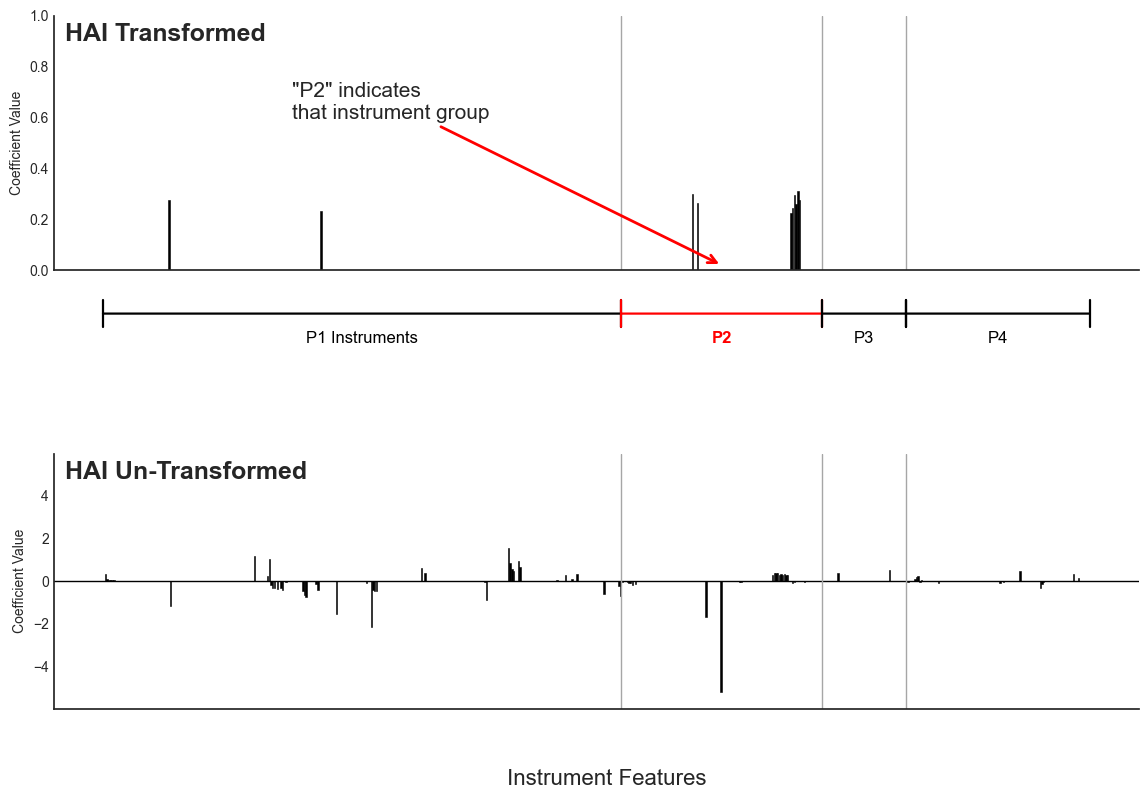

Saved figure to: C:\Users\jason\ODU\cutlass_demo\cases\HAI\figures\hai_attack_p2_sm_cutlass_coefficients.png


In [6]:
figure = plot_hai_coefficient_figure(
    rect_result['coef'],
    raw_result['coef'],
    feature_order,
    highlight_group=PLOT_HIGHLIGHT_GROUP,
)

output_name = f'hai_{TARGET_KEY}{split_suffix}_cutlass_coefficients.png'
output_path = FIG_DIR / output_name
figure.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved figure to:', output_path)


In [7]:
group_summary = pd.concat(
    {
        'Transformed': coefficient_group_summary(rect_result['coef']),
        'Un-Transformed': coefficient_group_summary(raw_result['coef']),
    },
    axis=1,
)
display(group_summary)

rect_top = rect_result['coef'].sort_values(ascending=False).head(20).rename('Transformed view')
rect_support_top = rect_result['coef_support'].sort_values(ascending=False).head(20).rename('Abs support')
rect_full_top = rect_result['coef_full'].sort_values(key=np.abs, ascending=False).head(20).rename('Expanded transformed')
raw_top = raw_result['coef'].sort_values(key=np.abs, ascending=False).head(20).rename('Un-Transformed')
display(pd.concat([rect_top, rect_support_top, rect_full_top, raw_top], axis=1))


Transformed                     Un-Transformed                     
      nonzero_count   abs_sum   max_abs  nonzero_count    abs_sum   max_abs
group                                                                      
P2               37  3.963334  0.311827             25  10.959205  5.178809
P1               32  1.477374  0.275251             50  22.943236  2.146290
P4               10  1.004039  0.186664             25   2.335793  0.481209
P3                0  0.000000  0.000000              2   0.917749  0.522224

,Transformed view,Abs support,Expanded transformed,Un-Transformed
P2_VYT02_06,0.311827,0.311827,-0.311827,NaN
P2_SD01_03,0.299801,0.299801,0.299801,NaN
P2_VYT02_04,0.297360,0.297360,-0.297360,NaN
P2_VYT02_07,0.275769,0.275769,-0.275769,NaN
P1_B3005_10,0.275251,0.275251,0.275251,NaN
P2_SD01_06,0.264104,0.264104,0.264104,NaN
P2_VYT02_05,0.260545,0.260545,-0.260545,NaN
P2_VYT02_03,0.244903,0.244903,-0.244903,NaN
P1_FCV03Z_01,0.232030,0.232030,0.232030,NaN
P2_VYT02_02,0.224960,0.224960,-0.224960,NaN
